# Linear Blobs Investigation

This notebook investigates teacher-surrogate disagreement on a controlled linear blobs dataset.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Synthetic Linear Blobs Data Generation

We generate a synthetic 2D binary classification dataset consisting of two Gaussian blobs centered at $(-1.4, 0)$ and $(1.4, 0)$. The dataset includes configurable standard deviation and isotropic Gaussian noise to create overlapping decision regions, facilitating controlled experiments on teacher-surrogate decision boundary alignment.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [4]:
# -----------------------------------------------------------------------------
# Linear blobs data
# -----------------------------------------------------------------------------

def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


### Teacher MLP and Surrogate Model Training

Here we train a 2-hidden-layer (64 units each) MLP teacher using binary cross-entropy on the synthetic dataset. Once the teacher is trained, we extract its hard predictions and train a suite of surrogate models (Logistic Regression, Calibrated Linear SVC, Decision Trees of varying depth, and a single-hidden-layer small MLP) to mimic the teacher's behavior.

In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


In [6]:
# -----------------------------------------------------------------------------
# Surrogates
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Global and Decision-Boundary Fidelity Metrics

We evaluate the fidelity of the surrogate models compared to the teacher. Crucially, we introduce an $\epsilon$-margin around the teacher's decision boundary (where $p(y=1) \in [0.5 - \epsilon, 0.5 + \epsilon]$) to compute boundary fidelity separately from non-boundary fidelity. This allows us to quantify the "boundary gap": the drop in fidelity specifically in the ambiguous regions near the teacher's decision boundary.

In [7]:
# -----------------------------------------------------------------------------
# Metrics
# -----------------------------------------------------------------------------

def compute_metrics(y_true, teacher_p, surrogate_p, eps=0.10):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)

    boundary_mask = np.abs(teacher_p - 0.5) <= eps
    nonboundary_mask = ~boundary_mask

    metrics = {
        "teacher_task_accuracy": accuracy_score(y_true, teacher_y),
        "surrogate_task_accuracy": accuracy_score(y_true, surrogate_y),
        "global_fidelity": accuracy_score(teacher_y, surrogate_y),
        "probability_mse": mean_squared_error(teacher_p, surrogate_p),
        "n_boundary_points": int(boundary_mask.sum()),
        "boundary_fraction": float(boundary_mask.mean()),
    }

    if boundary_mask.sum() > 0:
        metrics["boundary_fidelity"] = accuracy_score(teacher_y[boundary_mask], surrogate_y[boundary_mask])
        metrics["boundary_task_accuracy"] = accuracy_score(y_true[boundary_mask], surrogate_y[boundary_mask])
    else:
        metrics["boundary_fidelity"] = np.nan
        metrics["boundary_task_accuracy"] = np.nan

    if nonboundary_mask.sum() > 0:
        metrics["nonboundary_fidelity"] = accuracy_score(teacher_y[nonboundary_mask], surrogate_y[nonboundary_mask])
    else:
        metrics["nonboundary_fidelity"] = np.nan

    metrics["boundary_gap"] = metrics["global_fidelity"] - metrics["boundary_fidelity"]
    return metrics


In [8]:
def make_grid(X, margin=0.7, grid_size=400):
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


In [9]:
# -----------------------------------------------------------------------------
# Single-seed visual diagnosis
# -----------------------------------------------------------------------------

def run_single_case(seed=0, surrogate_name="logistic_regression", eps=0.10, n_samples=1500):
    X, y = make_linear_blobs(n_samples=n_samples, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)

    metrics = compute_metrics(y_test, teacher_test_p, surrogate_test_p, eps=eps)

    xx, yy, grid = make_grid(X)
    teacher_grid_p = teacher_probs(teacher, grid).reshape(xx.shape)
    surrogate_grid_p = surrogate_probs(surrogate, grid).reshape(xx.shape)
    teacher_grid_y = (teacher_grid_p >= 0.5).astype(int)
    surrogate_grid_y = (surrogate_grid_p >= 0.5).astype(int)
    disagreement = (teacher_grid_y != surrogate_grid_y).astype(int)
    boundary_region = (np.abs(teacher_grid_p - 0.5) <= eps).astype(int)

    teacher_test_y = (teacher_test_p >= 0.5).astype(int)
    surrogate_test_y = (surrogate_test_p >= 0.5).astype(int)
    boundary_mask_test = np.abs(teacher_test_p - 0.5) <= eps
    disagreement_test = teacher_test_y != surrogate_test_y

    return {
        "seed": seed,
        "surrogate_name": surrogate_name,
        "eps": eps,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "teacher": teacher,
        "surrogate": surrogate,
        "teacher_test_p": teacher_test_p,
        "surrogate_test_p": surrogate_test_p,
        "teacher_test_y": teacher_test_y,
        "surrogate_test_y": surrogate_test_y,
        "boundary_mask_test": boundary_mask_test,
        "disagreement_test": disagreement_test,
        "metrics": metrics,
        "xx": xx,
        "yy": yy,
        "teacher_grid_p": teacher_grid_p,
        "surrogate_grid_p": surrogate_grid_p,
        "disagreement": disagreement,
        "boundary_region": boundary_region,
    }


### Spatial Disagreement and Decision Boundary Visualization

We visualize the spatial distribution of the teacher-surrogate disagreement over a dense 2D grid. By overlaying the training points, the teacher's decision boundary, and the surrogate's decision boundary, we qualitatively assess where the surrogate models fail to capture the teacher's non-linearities or margins.

In [10]:
def plot_single_case(case):
    X_test = case["X_test"]
    y_test = case["y_test"]
    xx = case["xx"]
    yy = case["yy"]
    teacher_grid_p = case["teacher_grid_p"]
    surrogate_grid_p = case["surrogate_grid_p"]
    disagreement = case["disagreement"]
    boundary_region = case["boundary_region"]
    boundary_mask_test = case["boundary_mask_test"]
    disagreement_test = case["disagreement_test"]
    metrics = case["metrics"]

    fig, axes = plt.subplots(1, 5, figsize=(27, 5))

    axes[0].contourf(xx, yy, teacher_grid_p, levels=30, alpha=0.85)
    axes[0].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[0].set_title("Teacher probability + boundary")

    axes[1].contourf(xx, yy, surrogate_grid_p, levels=30, alpha=0.85)
    axes[1].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2)
    axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[1].set_title("Surrogate probability + boundary")

    axes[2].contourf(xx, yy, disagreement, levels=[-0.1, 0.5, 1.1], alpha=0.85)
    axes[2].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[2].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2, linestyles="--")
    axes[2].set_title("Grid disagreement")

    axes[3].contourf(xx, yy, boundary_region, levels=[-0.1, 0.5, 1.1], alpha=0.85)
    axes[3].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[3].scatter(
        X_test[boundary_mask_test, 0],
        X_test[boundary_mask_test, 1],
        s=25,
        edgecolor="k",
        linewidth=0.5,
        label="test points in band",
    )
    axes[3].set_title("Boundary band + test points")

    axes[4].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=14, alpha=0.35)
    axes[4].scatter(
        X_test[disagreement_test, 0],
        X_test[disagreement_test, 1],
        s=45,
        marker="x",
        linewidth=1.5,
        label="test disagreement",
    )
    axes[4].scatter(
        X_test[boundary_mask_test, 0],
        X_test[boundary_mask_test, 1],
        s=40,
        facecolors="none",
        edgecolor="k",
        linewidth=1.0,
        label="boundary band",
    )
    axes[4].set_title("Test-set disagreement / boundary overlap")
    axes[4].legend(loc="best")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(
        f"linear_blobs / {case['surrogate_name']} / seed={case['seed']}: "
        f"global={metrics['global_fidelity']:.3f}, "
        f"boundary={metrics['boundary_fidelity']:.3f}, "
        f"gap={metrics['boundary_gap']:.3f}, "
        f"n_boundary={metrics['n_boundary_points']}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


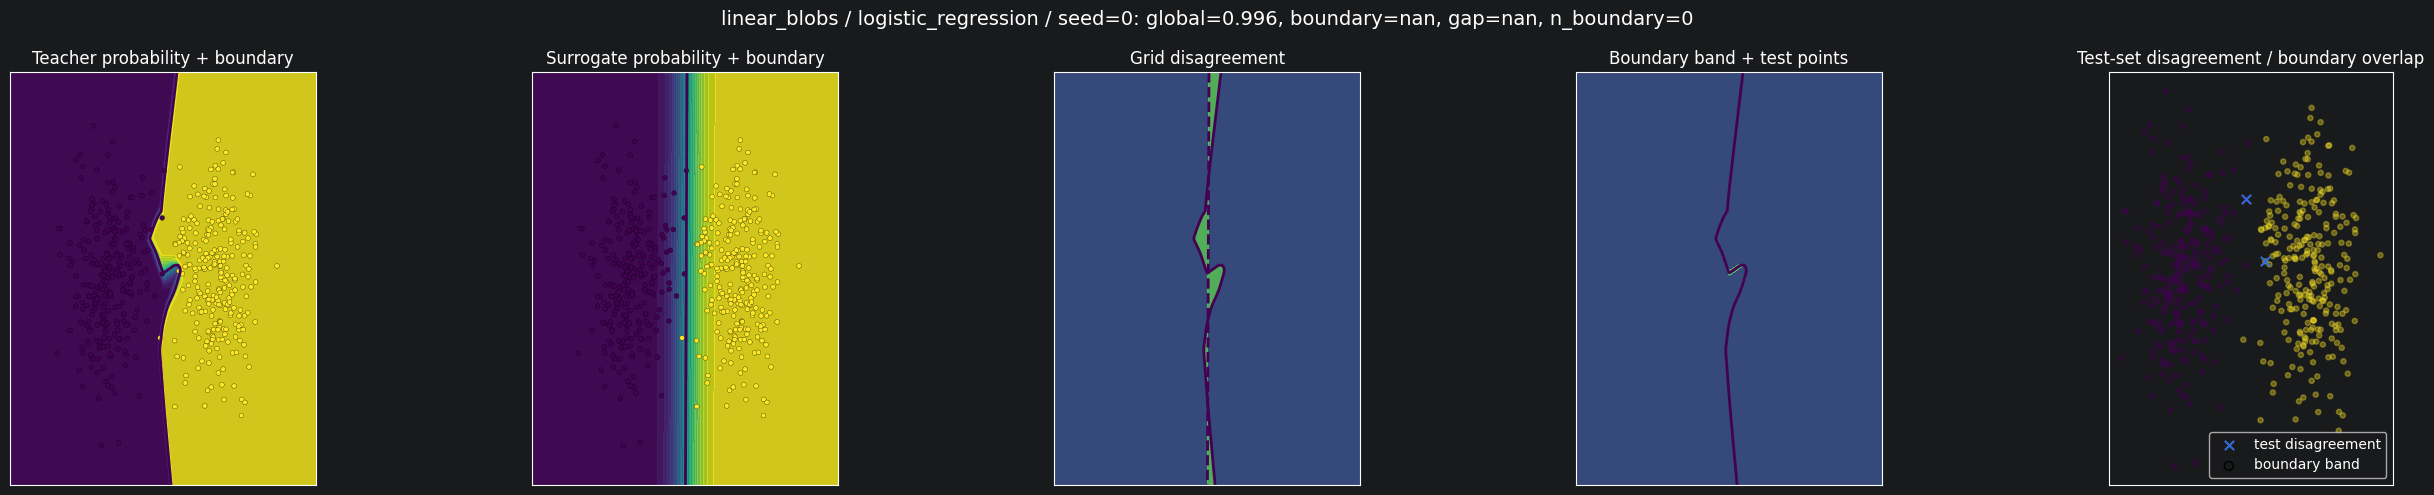

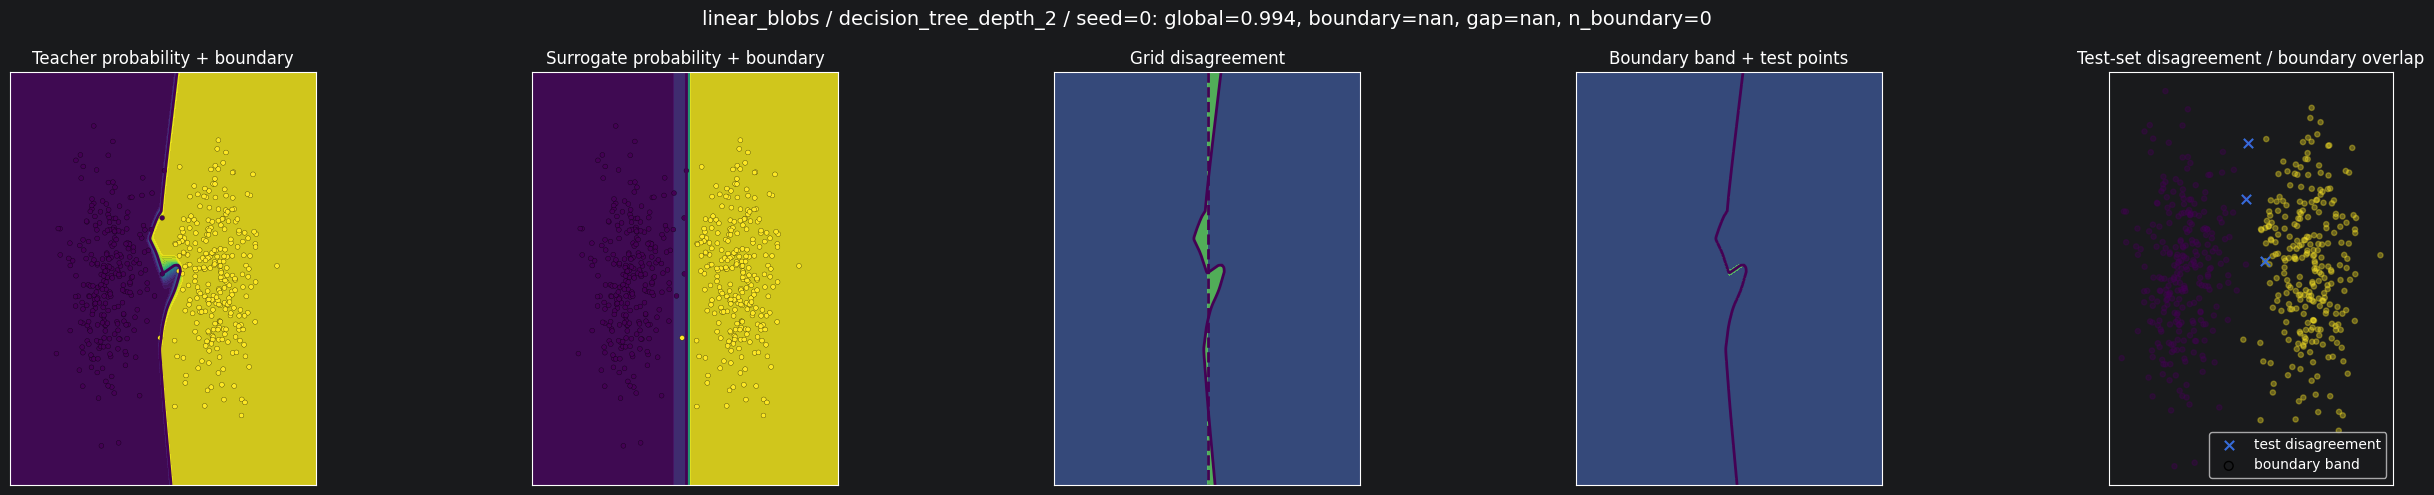

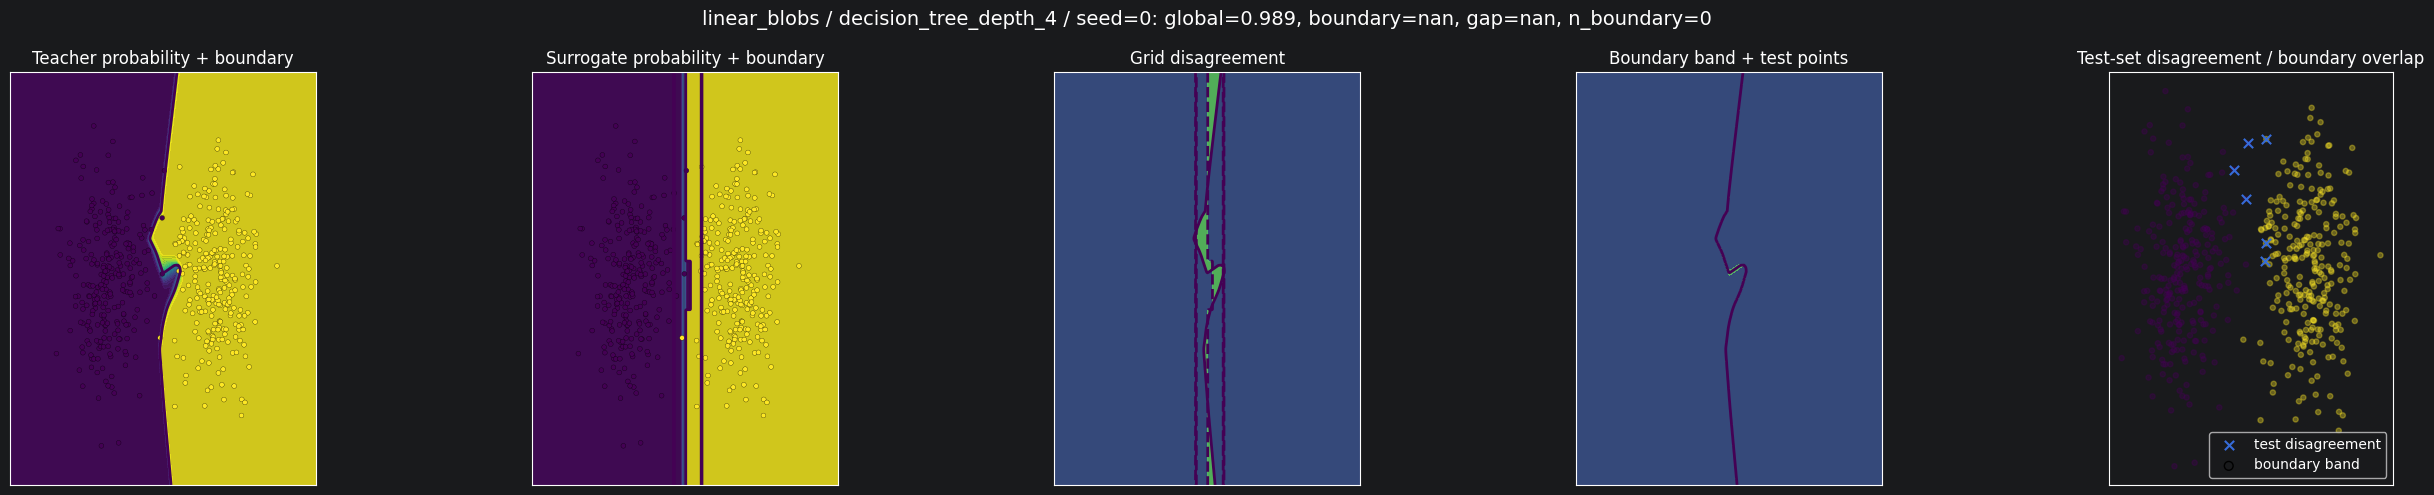

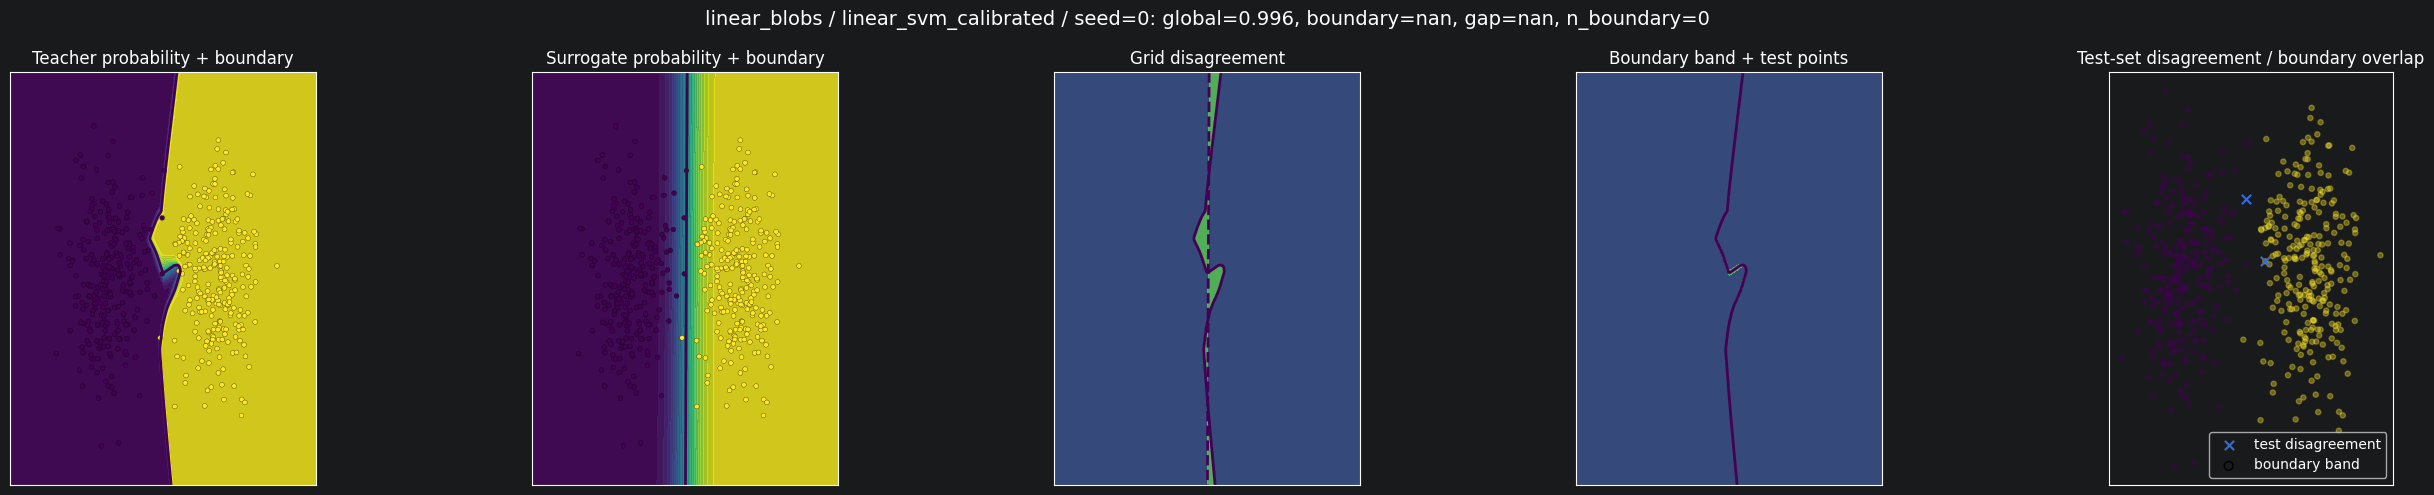

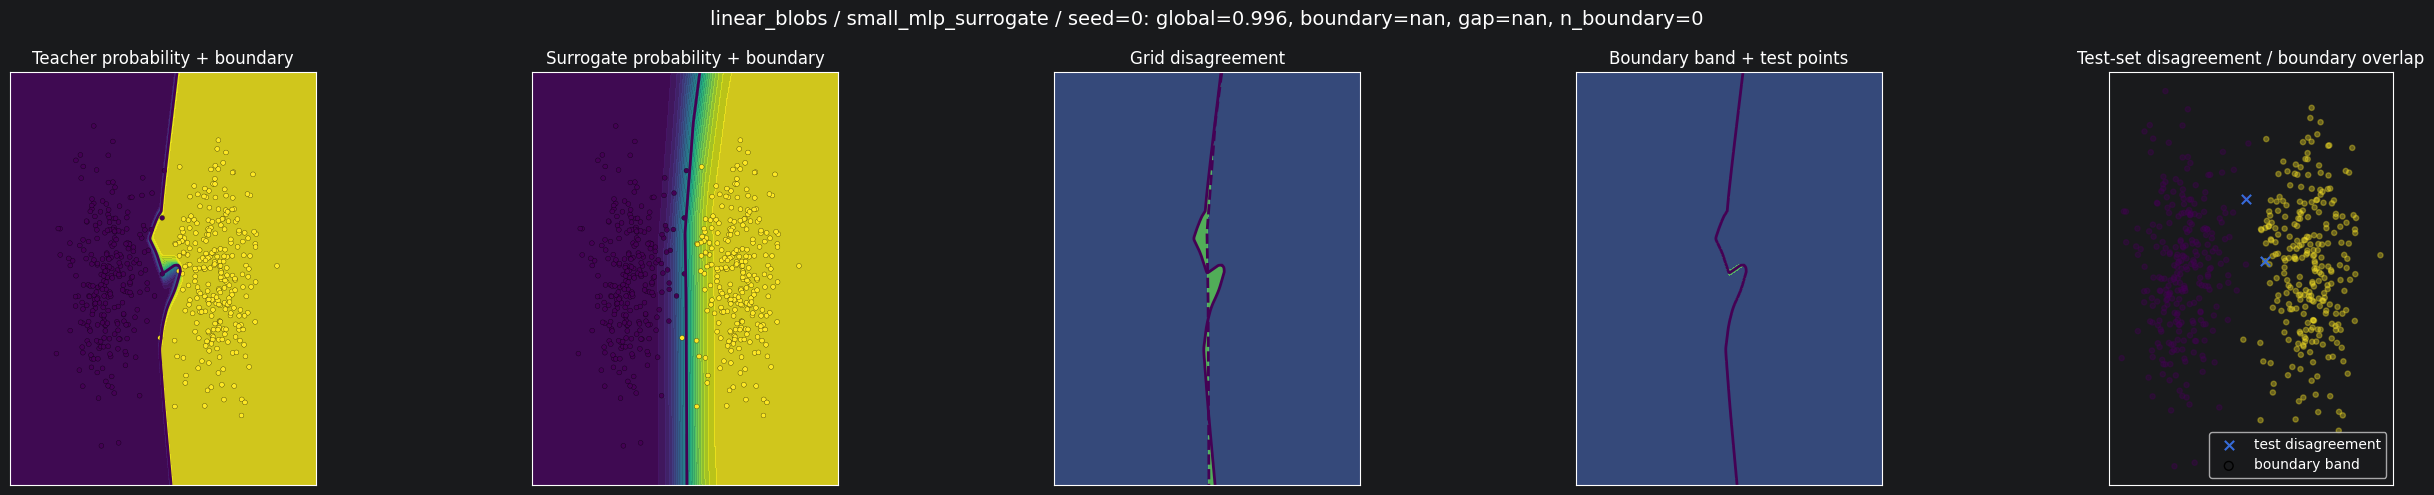

In [11]:
for surrogate_name in [
    "logistic_regression",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "linear_svm_calibrated",
    "small_mlp_surrogate",
]:
    case = run_single_case(seed=0, surrogate_name=surrogate_name, eps=0.10, n_samples=1500)
    plot_single_case(case)


In [12]:
# -----------------------------------------------------------------------------
# Multi-seed diagnostics: how many boundary points are we using?
# -----------------------------------------------------------------------------

def run_metric_only(seed, surrogate_name, eps=0.10, n_samples=1500):
    case = run_single_case(seed=seed, surrogate_name=surrogate_name, eps=eps, n_samples=n_samples)
    row = case["metrics"].copy()
    row["seed"] = seed
    row["surrogate"] = surrogate_name
    row["eps"] = eps
    row["n_samples"] = n_samples
    return row


In [13]:
seeds = list(range(10))
surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]
eps_values = [0.05, 0.10, 0.15, 0.20]

rows = []
for eps in eps_values:
    print(f"epsilon={eps}")
    for seed in seeds:
        for surrogate_name in surrogates:
            rows.append(run_metric_only(seed, surrogate_name, eps=eps, n_samples=1500))

results = pd.DataFrame(rows)
results


epsilon=0.05
epsilon=0.1
epsilon=0.15
epsilon=0.2


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,seed,surrogate,eps,n_samples
0,0.994286,0.998095,0.996190,0.003057,0,0.0,NaN,NaN,0.996190,NaN,0,logistic_regression,0.05,1500
1,0.994286,0.998095,0.996190,0.002905,0,0.0,NaN,NaN,0.996190,NaN,0,linear_svm_calibrated,0.05,1500
2,0.994286,0.996190,0.994286,0.002944,0,0.0,NaN,NaN,0.994286,NaN,0,decision_tree_depth_2,0.05,1500
3,0.994286,0.990476,0.988571,0.009141,0,0.0,NaN,NaN,0.988571,NaN,0,decision_tree_depth_4,0.05,1500
4,0.994286,0.998095,0.996190,0.002863,0,0.0,NaN,NaN,0.996190,NaN,0,small_mlp_surrogate,0.05,1500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.992381,0.992381,1.000000,0.003168,0,0.0,NaN,NaN,1.000000,NaN,9,logistic_regression,0.20,1500
196,0.992381,0.992381,1.000000,0.002837,0,0.0,NaN,NaN,1.000000,NaN,9,linear_svm_calibrated,0.20,1500
197,0.992381,0.992381,1.000000,0.000187,0,0.0,NaN,NaN,1.000000,NaN,9,decision_tree_depth_2,0.20,1500
198,0.992381,0.992381,1.000000,0.000194,0,0.0,NaN,NaN,1.000000,NaN,9,decision_tree_depth_4,0.20,1500


### Multi-seed Robustness, Sample Size Sensitivity, and Artifact Export

We aggregate results across multiple random seeds, testing sensitivity to the $\epsilon$-margin width, the training sample size, and extracting fidelity metrics conditioned on confidence bins. The summary statistics and raw tabular results are exported to CSVs for downstream inclusion in the paper.

In [14]:
results.to_csv("linear_blobs_boundary_count_diagnostics_raw.csv", index=False)
print("Saved linear_blobs_boundary_count_diagnostics_raw.csv")


Saved linear_blobs_boundary_count_diagnostics_raw.csv


In [15]:
summary = (
    results
    .groupby(["surrogate", "eps"])
    .agg(
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        n_boundary_mean=("n_boundary_points", "mean"),
        n_boundary_min=("n_boundary_points", "min"),
        n_boundary_max=("n_boundary_points", "max"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
    )
    .reset_index()
)
summary


,surrogate,eps,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,boundary_gap_mean,boundary_gap_std,n_boundary_mean,n_boundary_min,n_boundary_max,boundary_fraction_mean
0,decision_tree_depth_2,0.05,0.994286,0.994286,0.997333,0.002048,NaN,NaN,0.997333,NaN,NaN,0.0,0,0,0.000000
1,decision_tree_depth_2,0.10,0.994286,0.994286,0.997333,0.002048,0.500000,0.707107,0.997524,0.499048,0.705760,0.2,0,1,0.000381
2,decision_tree_depth_2,0.15,0.994286,0.994286,0.997333,0.002048,0.500000,0.577350,0.997713,0.497143,0.577356,0.4,0,1,0.000762
3,decision_tree_depth_2,0.20,0.994286,0.994286,0.997333,0.002048,0.666667,0.471405,0.997713,0.330476,0.470962,0.8,0,3,0.001524
4,decision_tree_depth_4,0.05,0.994286,0.993143,0.996190,0.003810,NaN,NaN,0.996190,NaN,NaN,0.0,0,0,0.000000
5,decision_tree_depth_4,0.10,0.994286,0.993143,0.996190,0.003810,0.500000,0.707107,0.996381,0.499048,0.705760,0.2,0,1,0.000381
6,decision_tree_depth_4,0.15,0.994286,0.993143,0.996190,0.003810,0.500000,0.577350,0.996569,0.495714,0.579019,0.4,0,1,0.000762
7,decision_tree_depth_4,0.20,0.994286,0.993143,0.996190,0.003810,0.666667,0.471405,0.996569,0.329048,0.472328,0.8,0,3,0.001524
8,linear_svm_calibrated,0.05,0.994286,0.994476,0.998286,0.001668,NaN,NaN,0.998286,NaN,NaN,0.0,0,0,0.000000
9,linear_svm_calibrated,0.10,0.994286,0.994476,0.998286,0.001668,0.500000,0.707107,0.998476,0.498095,0.704413,0.2,0,1,0.000381


In [16]:
summary.to_csv("linear_blobs_boundary_count_diagnostics_summary.csv", index=False)
print("Saved linear_blobs_boundary_count_diagnostics_summary.csv")


Saved linear_blobs_boundary_count_diagnostics_summary.csv


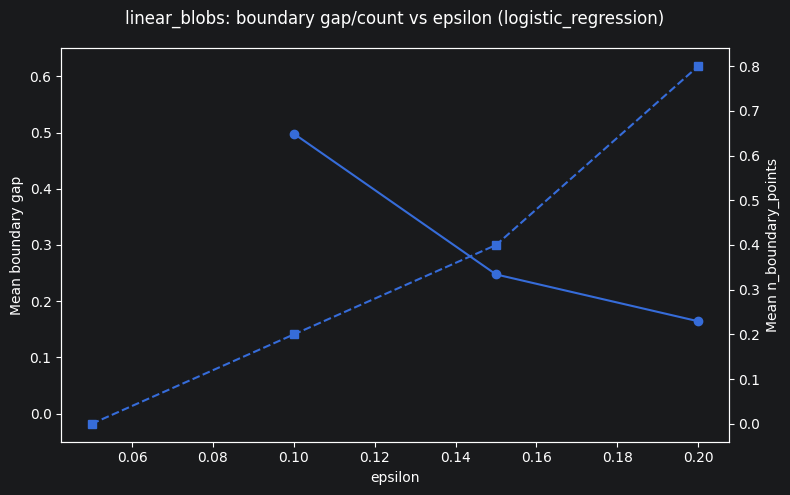

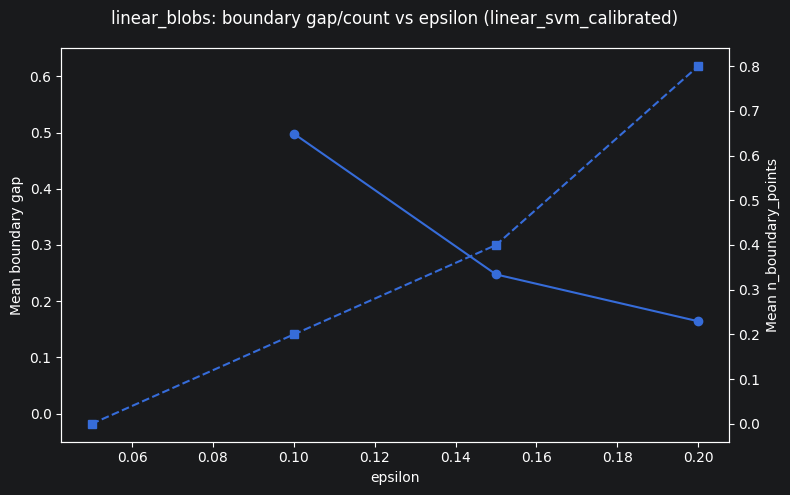

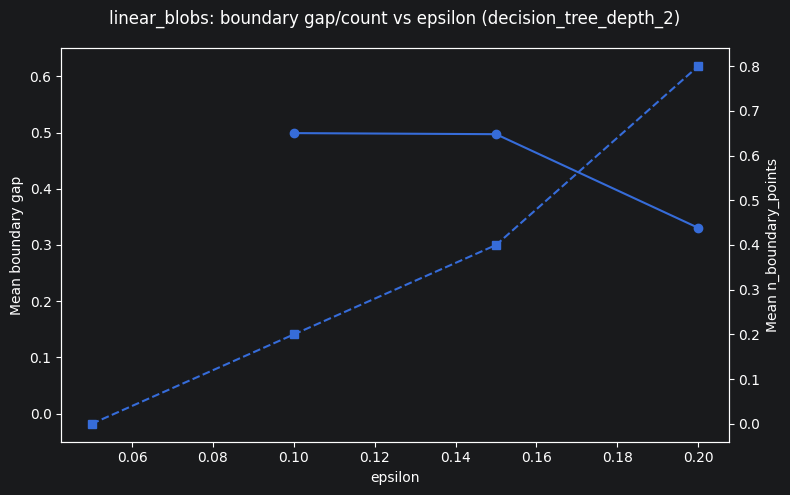

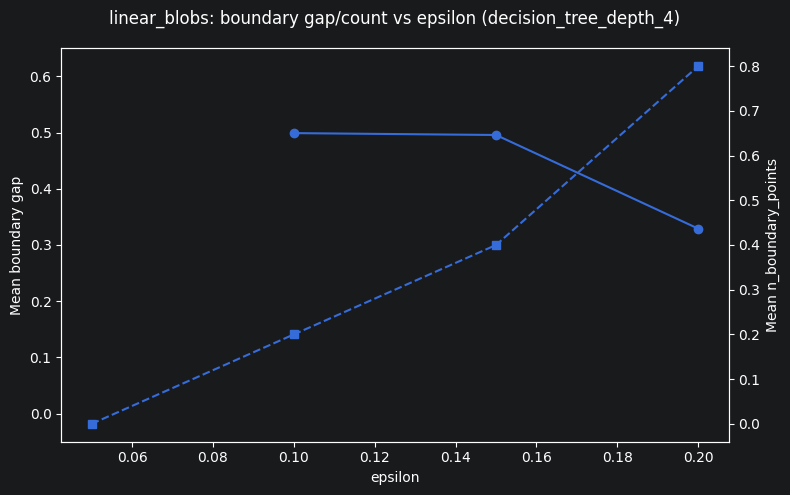

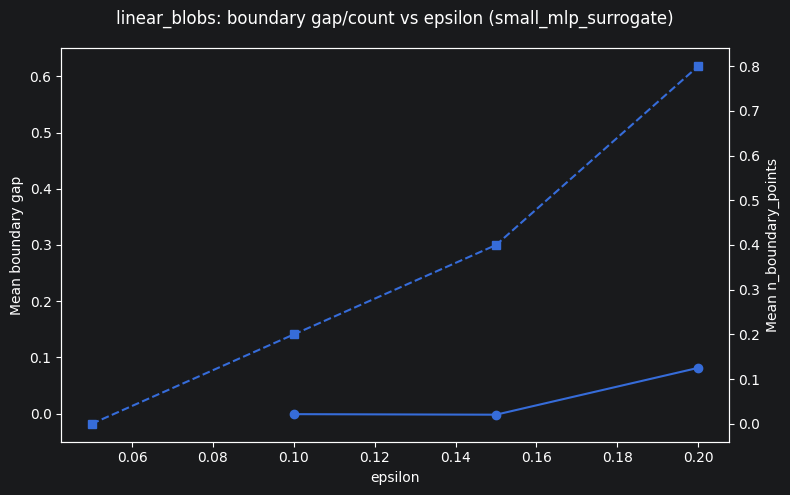

In [17]:
# Plot boundary count and boundary gap as epsilon varies.
for surrogate_name in surrogates:
    subset = summary[summary["surrogate"] == surrogate_name]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(subset["eps"], subset["boundary_gap_mean"], marker="o", label="Boundary gap")
    ax1.set_xlabel("epsilon")
    ax1.set_ylabel("Mean boundary gap")
    ax1.set_ylim(-0.05, 0.65)

    ax2 = ax1.twinx()
    ax2.plot(subset["eps"], subset["n_boundary_mean"], marker="s", linestyle="--", label="Boundary count")
    ax2.set_ylabel("Mean n_boundary_points")

    fig.suptitle(f"linear_blobs: boundary gap/count vs epsilon ({surrogate_name})")
    fig.tight_layout()
    plt.show()


In [18]:
# -----------------------------------------------------------------------------
# Larger sample-size check
# -----------------------------------------------------------------------------
# Boundary regions are small for linearly separable data. If the original result
# is unstable because too few boundary points exist in the held-out test set,
# the boundary fidelity should stabilize as n_samples increases.

sample_sizes = [1500, 3000, 6000, 10000]
eps = 0.10
large_rows = []

for n_samples in sample_sizes:
    print(f"n_samples={n_samples}")
    for seed in seeds:
        for surrogate_name in surrogates:
            large_rows.append(run_metric_only(seed, surrogate_name, eps=eps, n_samples=n_samples))

large_results = pd.DataFrame(large_rows)
large_results


n_samples=1500
n_samples=3000
n_samples=6000
n_samples=10000


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,seed,surrogate,eps,n_samples
0,0.994286,0.998095,0.996190,0.003057,0,0.000000,NaN,NaN,0.996190,NaN,0,logistic_regression,0.1,1500
1,0.994286,0.998095,0.996190,0.002905,0,0.000000,NaN,NaN,0.996190,NaN,0,linear_svm_calibrated,0.1,1500
2,0.994286,0.996190,0.994286,0.002944,0,0.000000,NaN,NaN,0.994286,NaN,0,decision_tree_depth_2,0.1,1500
3,0.994286,0.990476,0.988571,0.009141,0,0.000000,NaN,NaN,0.988571,NaN,0,decision_tree_depth_4,0.1,1500
4,0.994286,0.998095,0.996190,0.002863,0,0.000000,NaN,NaN,0.996190,NaN,0,small_mlp_surrogate,0.1,1500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.995143,0.994286,0.998571,0.000498,18,0.005143,0.777778,0.500000,0.999713,0.220794,9,logistic_regression,0.1,10000
196,0.995143,0.994571,0.998286,0.000481,18,0.005143,0.722222,0.555556,0.999713,0.276063,9,linear_svm_calibrated,0.1,10000
197,0.995143,0.994571,0.998286,0.000904,18,0.005143,0.833333,0.666667,0.999138,0.164952,9,decision_tree_depth_2,0.1,10000
198,0.995143,0.992857,0.996571,0.001463,18,0.005143,0.666667,0.500000,0.998277,0.329905,9,decision_tree_depth_4,0.1,10000


In [19]:
large_results.to_csv("linear_blobs_sample_size_sensitivity_raw.csv", index=False)
print("Saved linear_blobs_sample_size_sensitivity_raw.csv")


Saved linear_blobs_sample_size_sensitivity_raw.csv


In [20]:
large_summary = (
    large_results
    .groupby(["surrogate", "n_samples"])
    .agg(
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        n_boundary_mean=("n_boundary_points", "mean"),
        n_boundary_min=("n_boundary_points", "min"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
    )
    .reset_index()
)
large_summary


,surrogate,n_samples,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,boundary_gap_mean,boundary_gap_std,n_boundary_mean,n_boundary_min,boundary_fraction_mean
0,decision_tree_depth_2,1500,0.997333,0.002048,0.500000,0.707107,0.499048,0.705760,0.2,0,0.000381
1,decision_tree_depth_2,3000,0.996476,0.002202,0.500000,0.433013,0.496085,0.432054,1.6,0,0.001524
2,decision_tree_depth_2,6000,0.996762,0.001486,0.703131,0.263421,0.293959,0.262431,4.8,0,0.002286
3,decision_tree_depth_2,10000,0.997514,0.000852,0.607857,0.167337,0.389657,0.166562,9.1,5,0.002600
4,decision_tree_depth_4,1500,0.996190,0.003810,0.500000,0.707107,0.499048,0.705760,0.2,0,0.000381
5,decision_tree_depth_4,3000,0.996190,0.002376,0.444444,0.390868,0.551534,0.389842,1.6,0,0.001524
6,decision_tree_depth_4,6000,0.997762,0.000980,0.607319,0.337061,0.390670,0.336517,4.8,0,0.002286
7,decision_tree_depth_4,10000,0.997886,0.001229,0.668611,0.120895,0.329275,0.120019,9.1,5,0.002600
8,linear_svm_calibrated,1500,0.998286,0.001668,0.500000,0.707107,0.498095,0.704413,0.2,0,0.000381
9,linear_svm_calibrated,3000,0.997048,0.001875,0.638889,0.377308,0.357831,0.377215,1.6,0,0.001524


In [21]:
large_summary.to_csv("linear_blobs_sample_size_sensitivity_summary.csv", index=False)
print("Saved linear_blobs_sample_size_sensitivity_summary.csv")


Saved linear_blobs_sample_size_sensitivity_summary.csv


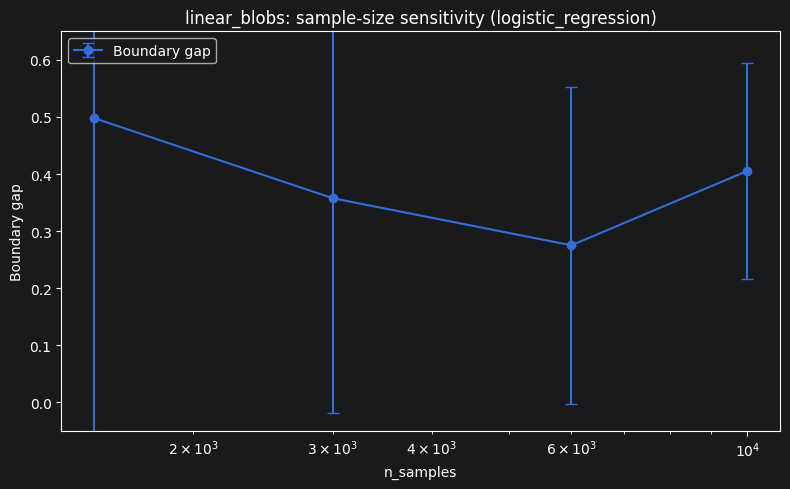

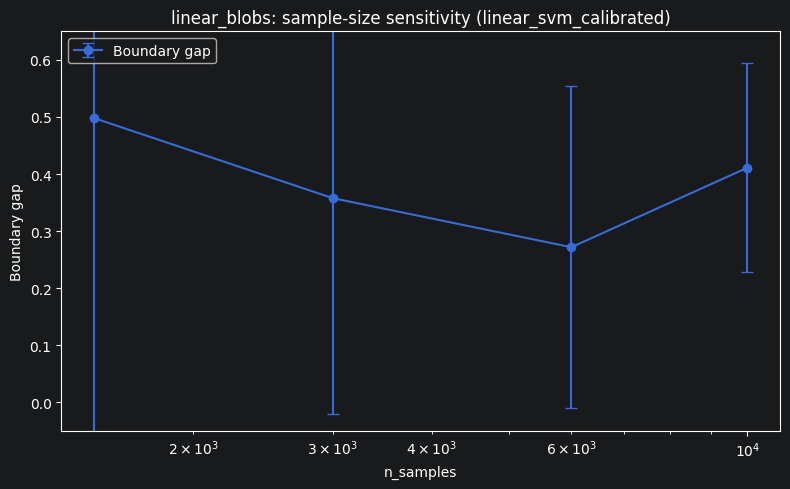

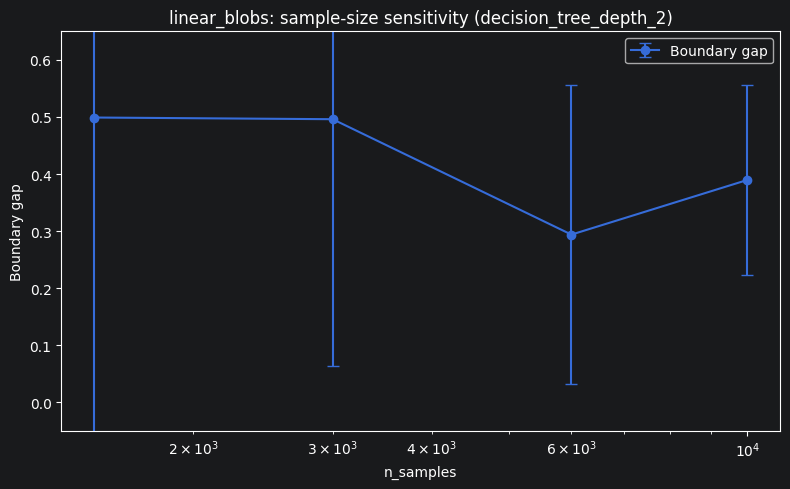

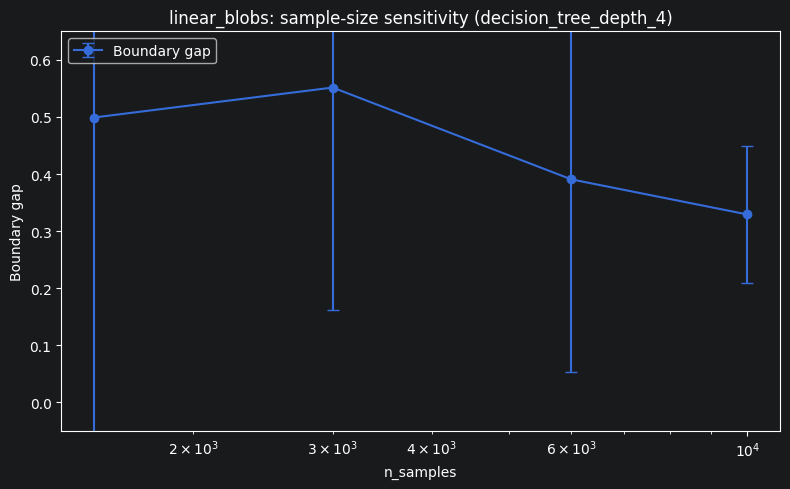

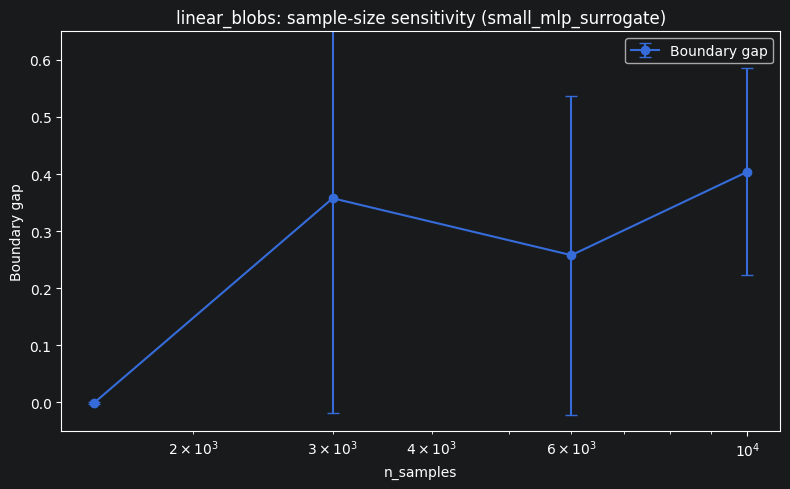

In [22]:
for surrogate_name in surrogates:
    subset = large_summary[large_summary["surrogate"] == surrogate_name]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        subset["n_samples"],
        subset["boundary_gap_mean"],
        yerr=subset["boundary_gap_std"],
        marker="o",
        capsize=4,
        label="Boundary gap",
    )
    ax.set_xscale("log")
    ax.set_xlabel("n_samples")
    ax.set_ylabel("Boundary gap")
    ax.set_title(f"linear_blobs: sample-size sensitivity ({surrogate_name})")
    ax.set_ylim(-0.05, 0.65)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [23]:
# -----------------------------------------------------------------------------
# Confidence-bin fidelity diagnostic
# -----------------------------------------------------------------------------

def confidence_bin_table(case, bins=None):
    if bins is None:
        bins = [0.50, 0.55, 0.60, 0.70, 0.80, 0.90, 1.00]

    teacher_p = case["teacher_test_p"]
    surrogate_p = case["surrogate_test_p"]
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)

    # Confidence is max probability assigned by teacher.
    teacher_conf = np.maximum(teacher_p, 1 - teacher_p)

    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        if hi == 1.00:
            mask = (teacher_conf >= lo) & (teacher_conf <= hi)
        else:
            mask = (teacher_conf >= lo) & (teacher_conf < hi)

        if mask.sum() == 0:
            fidelity = np.nan
            surrogate_acc = np.nan
        else:
            fidelity = accuracy_score(teacher_y[mask], surrogate_y[mask])
            surrogate_acc = accuracy_score(case["y_test"][mask], surrogate_y[mask])

        rows.append({
            "bin": f"{lo:.2f}-{hi:.2f}",
            "lo": lo,
            "hi": hi,
            "n": int(mask.sum()),
            "fraction": float(mask.mean()),
            "fidelity": fidelity,
            "surrogate_task_accuracy": surrogate_acc,
        })

    return pd.DataFrame(rows)



 logistic_regression


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN
2,0.60-0.70,0.60,0.70,1,0.001905,1.000000,1.000000
3,0.70-0.80,0.70,0.80,1,0.001905,0.000000,1.000000
4,0.80-0.90,0.80,0.90,3,0.005714,1.000000,0.666667
5,0.90-1.00,0.90,1.00,520,0.990476,0.998077,1.000000


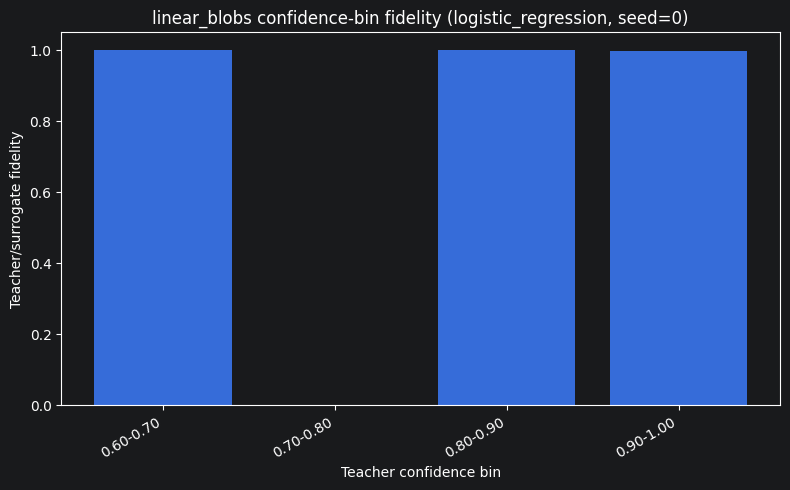


 linear_svm_calibrated


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN
2,0.60-0.70,0.60,0.70,1,0.001905,1.000000,1.000000
3,0.70-0.80,0.70,0.80,1,0.001905,0.000000,1.000000
4,0.80-0.90,0.80,0.90,3,0.005714,1.000000,0.666667
5,0.90-1.00,0.90,1.00,520,0.990476,0.998077,1.000000


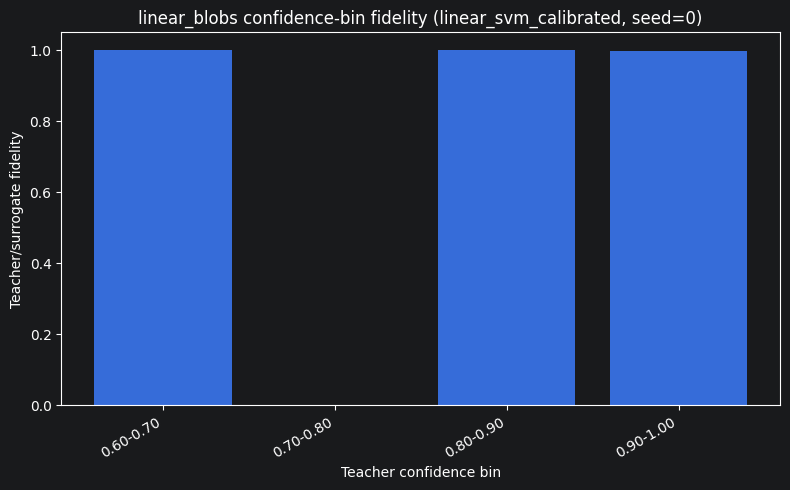


 decision_tree_depth_2


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN
2,0.60-0.70,0.60,0.70,1,0.001905,1.000000,1.000000
3,0.70-0.80,0.70,0.80,1,0.001905,0.000000,1.000000
4,0.80-0.90,0.80,0.90,3,0.005714,0.666667,0.333333
5,0.90-1.00,0.90,1.00,520,0.990476,0.998077,1.000000


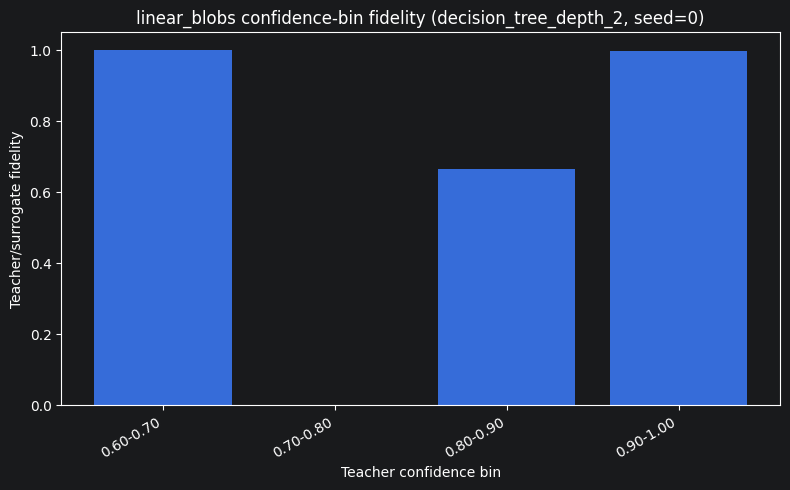


 decision_tree_depth_4


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN
2,0.60-0.70,0.60,0.70,1,0.001905,1.000000,1.000000
3,0.70-0.80,0.70,0.80,1,0.001905,0.000000,1.000000
4,0.80-0.90,0.80,0.90,3,0.005714,0.666667,0.333333
5,0.90-1.00,0.90,1.00,520,0.990476,0.992308,0.994231


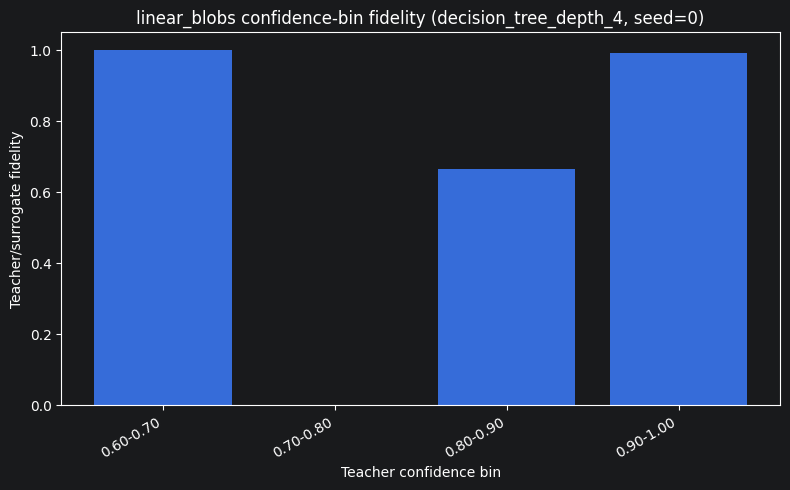


 small_mlp_surrogate


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN
2,0.60-0.70,0.60,0.70,1,0.001905,1.000000,1.000000
3,0.70-0.80,0.70,0.80,1,0.001905,0.000000,1.000000
4,0.80-0.90,0.80,0.90,3,0.005714,1.000000,0.666667
5,0.90-1.00,0.90,1.00,520,0.990476,0.998077,1.000000


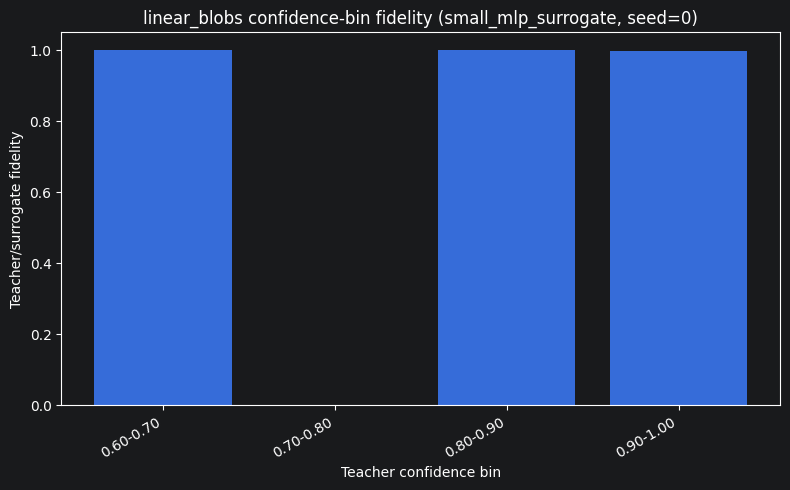

In [24]:
for surrogate_name in surrogates:
    case = run_single_case(seed=0, surrogate_name=surrogate_name, eps=0.10, n_samples=1500)
    bin_df = confidence_bin_table(case)
    print("\n", surrogate_name)
    display(bin_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(bin_df["bin"], bin_df["fidelity"])
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Teacher confidence bin")
    ax.set_ylabel("Teacher/surrogate fidelity")
    ax.set_title(f"linear_blobs confidence-bin fidelity ({surrogate_name}, seed=0)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [25]:
# Multi-seed confidence-bin summary for logistic regression and small MLP.
confidence_rows = []
for surrogate_name in ["logistic_regression", "small_mlp_surrogate"]:
    for seed in seeds:
        case = run_single_case(seed=seed, surrogate_name=surrogate_name, eps=0.10, n_samples=1500)
        bin_df = confidence_bin_table(case)
        bin_df["seed"] = seed
        bin_df["surrogate"] = surrogate_name
        confidence_rows.append(bin_df)

confidence_results = pd.concat(confidence_rows, ignore_index=True)
confidence_results


,bin,lo,hi,n,fraction,fidelity,surrogate_task_accuracy,seed,surrogate
0,0.50-0.55,0.50,0.55,0,0.000000,NaN,NaN,0,logistic_regression
1,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN,0,logistic_regression
2,0.60-0.70,0.60,0.70,1,0.001905,1.0,1.000000,0,logistic_regression
3,0.70-0.80,0.70,0.80,1,0.001905,0.0,1.000000,0,logistic_regression
4,0.80-0.90,0.80,0.90,3,0.005714,1.0,0.666667,0,logistic_regression
...,...,...,...,...,...,...,...,...,...
115,0.55-0.60,0.55,0.60,0,0.000000,NaN,NaN,9,small_mlp_surrogate
116,0.60-0.70,0.60,0.70,0,0.000000,NaN,NaN,9,small_mlp_surrogate
117,0.70-0.80,0.70,0.80,1,0.001905,1.0,1.000000,9,small_mlp_surrogate
118,0.80-0.90,0.80,0.90,1,0.001905,1.0,1.000000,9,small_mlp_surrogate


In [26]:
confidence_summary = (
    confidence_results
    .groupby(["surrogate", "bin", "lo", "hi"])
    .agg(
        n_mean=("n", "mean"),
        fraction_mean=("fraction", "mean"),
        fidelity_mean=("fidelity", "mean"),
        fidelity_std=("fidelity", "std"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
    )
    .reset_index()
    .sort_values(["surrogate", "lo"])
)
confidence_summary


,surrogate,bin,lo,hi,n_mean,fraction_mean,fidelity_mean,fidelity_std,surrogate_task_accuracy_mean
0,logistic_regression,0.50-0.55,0.50,0.55,0.0,0.000000,NaN,NaN,NaN
1,logistic_regression,0.55-0.60,0.55,0.60,0.2,0.000381,0.500000,0.707107,0.500000
2,logistic_regression,0.60-0.70,0.60,0.70,0.6,0.001143,0.875000,0.250000,0.625000
3,logistic_regression,0.70-0.80,0.70,0.80,0.7,0.001333,0.666667,0.516398,0.833333
4,logistic_regression,0.80-0.90,0.80,0.90,1.8,0.003429,0.791667,0.353553,0.875000
5,logistic_regression,0.90-1.00,0.90,1.00,521.7,0.993714,0.999233,0.000990,0.995784
6,small_mlp_surrogate,0.50-0.55,0.50,0.55,0.0,0.000000,NaN,NaN,NaN
7,small_mlp_surrogate,0.55-0.60,0.55,0.60,0.2,0.000381,1.000000,0.000000,1.000000
8,small_mlp_surrogate,0.60-0.70,0.60,0.70,0.6,0.001143,0.875000,0.250000,0.625000
9,small_mlp_surrogate,0.70-0.80,0.70,0.80,0.7,0.001333,0.666667,0.516398,0.833333


In [27]:
confidence_results.to_csv("linear_blobs_confidence_bin_raw.csv", index=False)
confidence_summary.to_csv("linear_blobs_confidence_bin_summary.csv", index=False)
print("Saved:")
print("- linear_blobs_confidence_bin_raw.csv")
print("- linear_blobs_confidence_bin_summary.csv")


Saved:
- linear_blobs_confidence_bin_raw.csv
- linear_blobs_confidence_bin_summary.csv


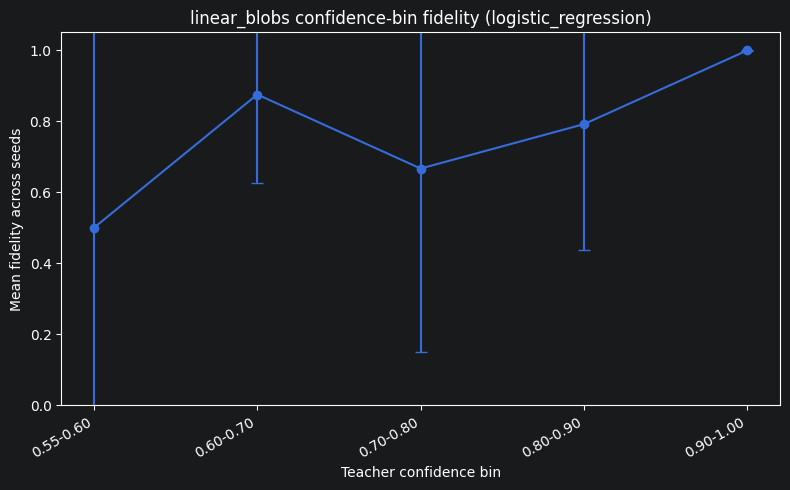

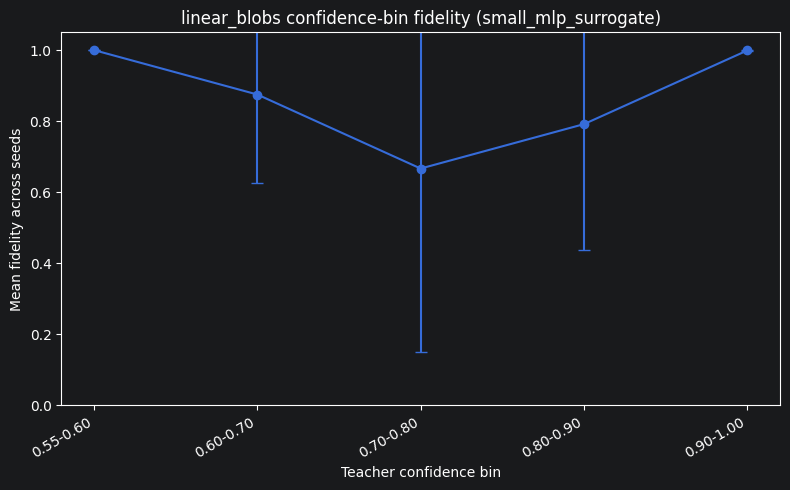

In [28]:
for surrogate_name in ["logistic_regression", "small_mlp_surrogate"]:
    subset = confidence_summary[confidence_summary["surrogate"] == surrogate_name]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        subset["bin"],
        subset["fidelity_mean"],
        yerr=subset["fidelity_std"],
        marker="o",
        capsize=4,
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Teacher confidence bin")
    ax.set_ylabel("Mean fidelity across seeds")
    ax.set_title(f"linear_blobs confidence-bin fidelity ({surrogate_name})")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
